## Importing libraries

In [4]:
pip install seaborn matplotlib scikit-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

## Data loading & Initial analysis

In [6]:
data = pd.read_csv("TrafficTwoMonth.csv")

In [7]:
data.head() #head of data

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,12:00:00 AM,10,Tuesday,13,2,2,24,41,normal
1,12:15:00 AM,10,Tuesday,14,1,1,36,52,normal
2,12:30:00 AM,10,Tuesday,10,2,2,32,46,normal
3,12:45:00 AM,10,Tuesday,10,2,2,36,50,normal
4,1:00:00 AM,10,Tuesday,11,2,1,34,48,normal


In [8]:
data.info() # information of dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5952 entries, 0 to 5951
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Time               5952 non-null   object
 1   Date               5952 non-null   int64 
 2   Day of the week    5952 non-null   object
 3   CarCount           5952 non-null   int64 
 4   BikeCount          5952 non-null   int64 
 5   BusCount           5952 non-null   int64 
 6   TruckCount         5952 non-null   int64 
 7   Total              5952 non-null   int64 
 8   Traffic Situation  5952 non-null   object
dtypes: int64(6), object(3)
memory usage: 418.6+ KB


In [9]:
data.describe() # statistical parameters of dataset

,Date,CarCount,BikeCount,BusCount,TruckCount,Total
count,5952.000000,5952.000000,5952.000000,5952.000000,5952.000000,5952.000000
mean,16.000000,65.440692,12.161458,12.912970,18.646337,109.161458
std,8.945023,44.749335,11.537944,12.497736,10.973139,55.996312
min,1.000000,5.000000,0.000000,0.000000,0.000000,21.000000
25%,8.000000,18.750000,3.000000,2.000000,10.000000,54.000000
50%,16.000000,62.000000,9.000000,10.000000,18.000000,104.000000
75%,24.000000,103.000000,19.000000,20.000000,27.000000,153.000000
max,31.000000,180.000000,70.000000,50.000000,60.000000,279.000000


## EDA - Exploratory Data Analysis

In [10]:
# checking for any missing values
def missingValues(data):
    missing_values = data.isnull().sum()
    missing_values
    print("Columns with Missing Values:")
    print(missing_values[missing_values > 0])
missingValues(data)

Columns with Missing Values:
Series([], dtype: int64)


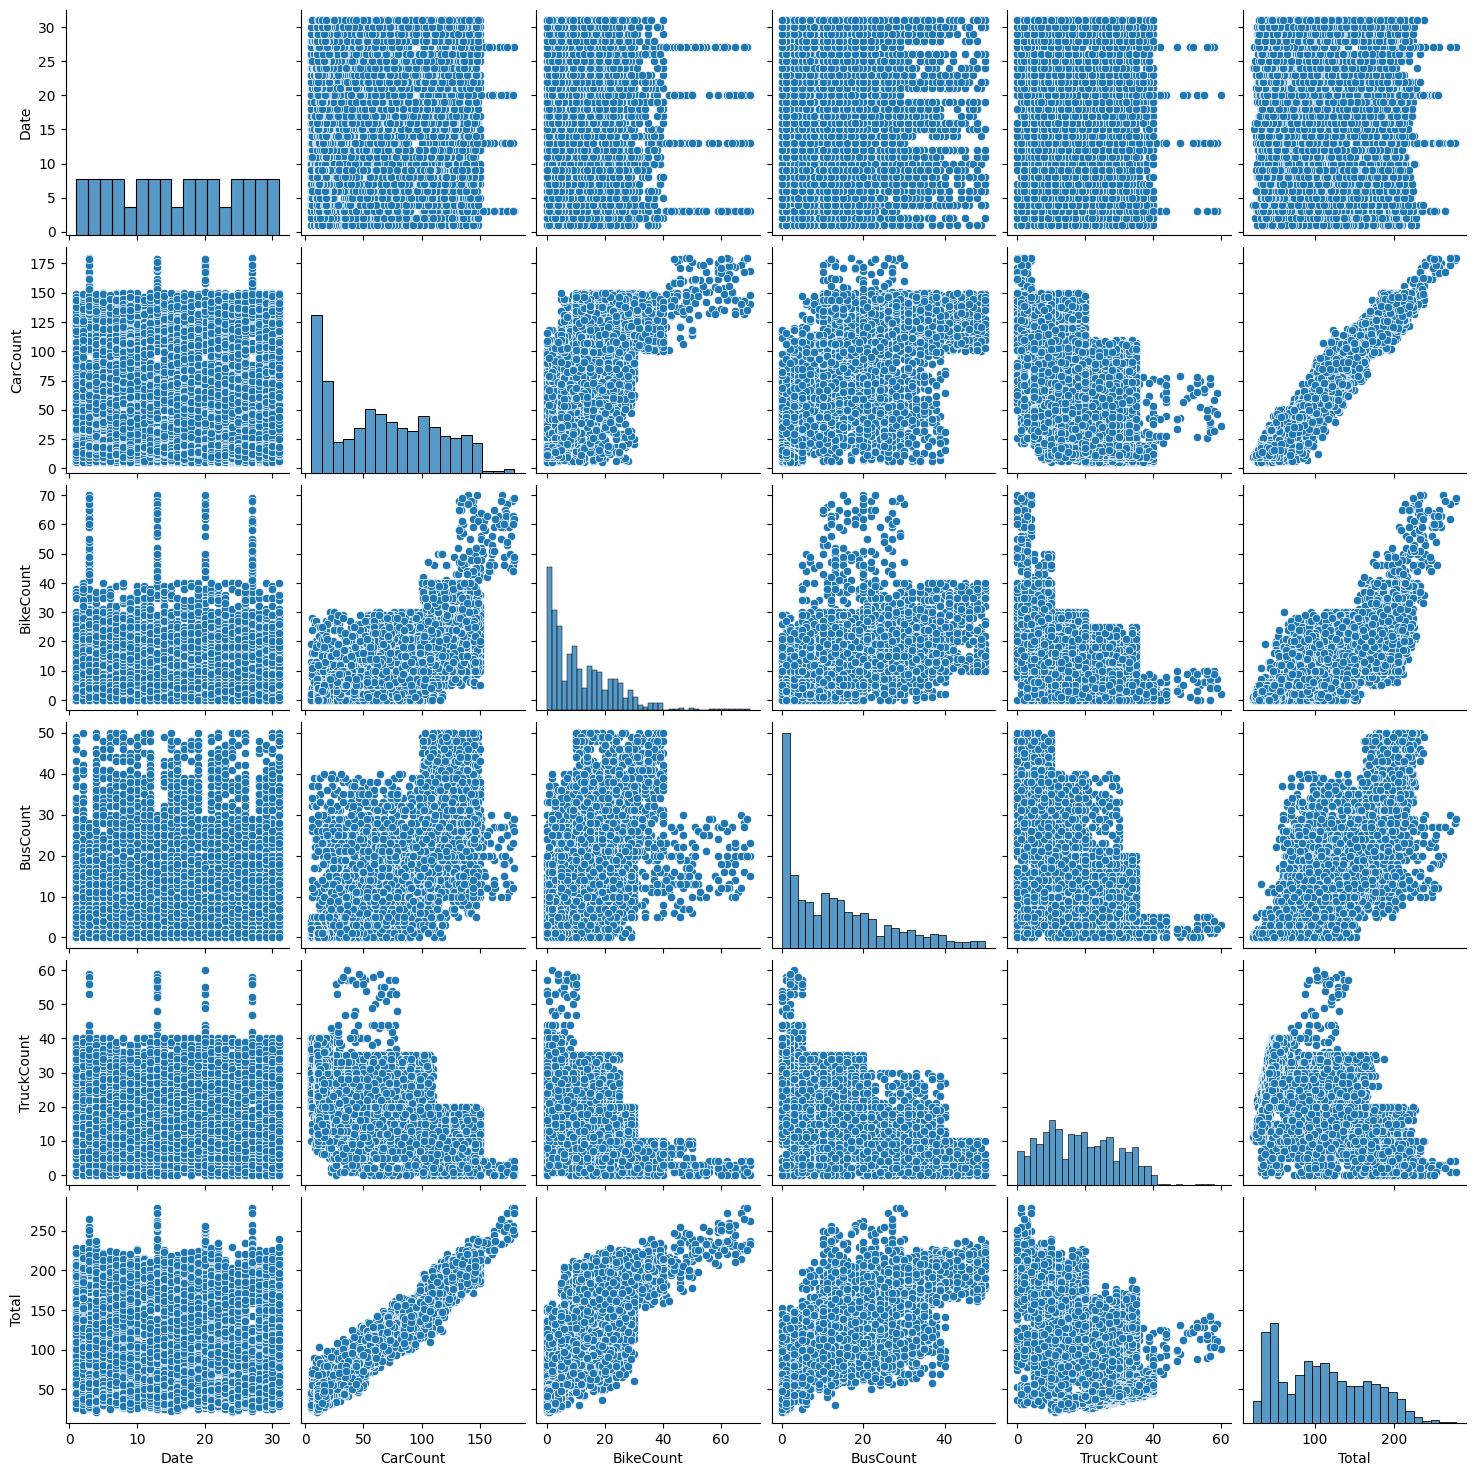

In [11]:
# Pairplot for numerical columns
def pairPlot(data):
    sns.pairplot(data, palette='pastel')
    plt.show()
pairPlot(data)

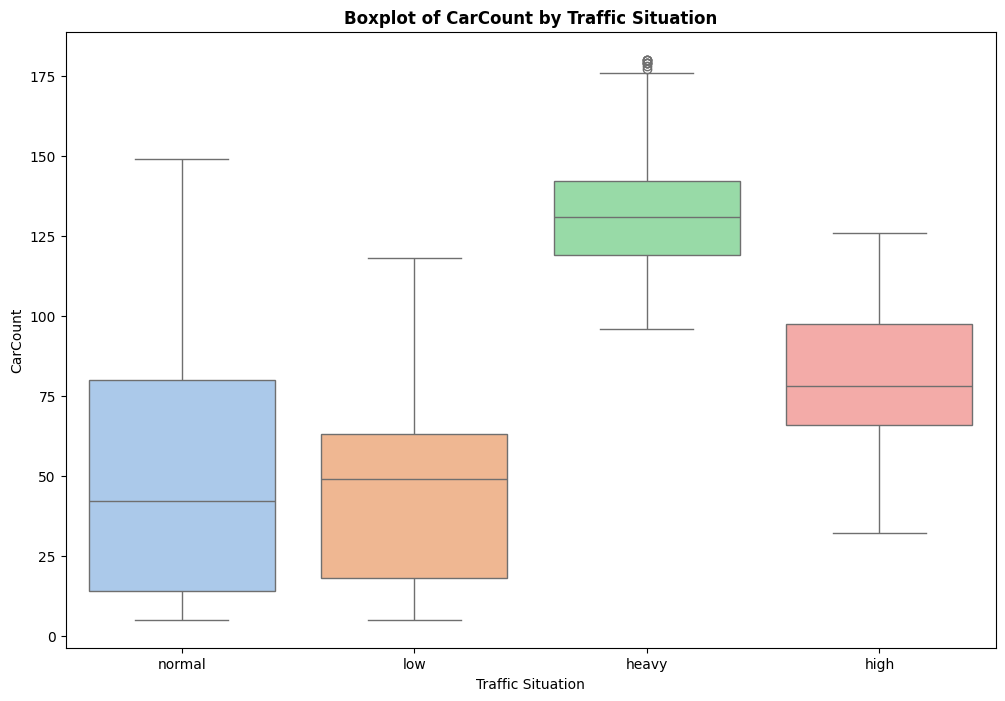

In [12]:
# Boxplot for traffic situations and numerical columns
def boxPlots(data):
    plt.figure(figsize=(12, 8))
    sns.boxplot(x='Traffic Situation', y='CarCount', data=data, palette='pastel')
    plt.title('Boxplot of CarCount by Traffic Situation', weight='bold')
    plt.show()
boxPlots(data)

In [13]:
numerical_columns = data.select_dtypes(include=['int64']).columns

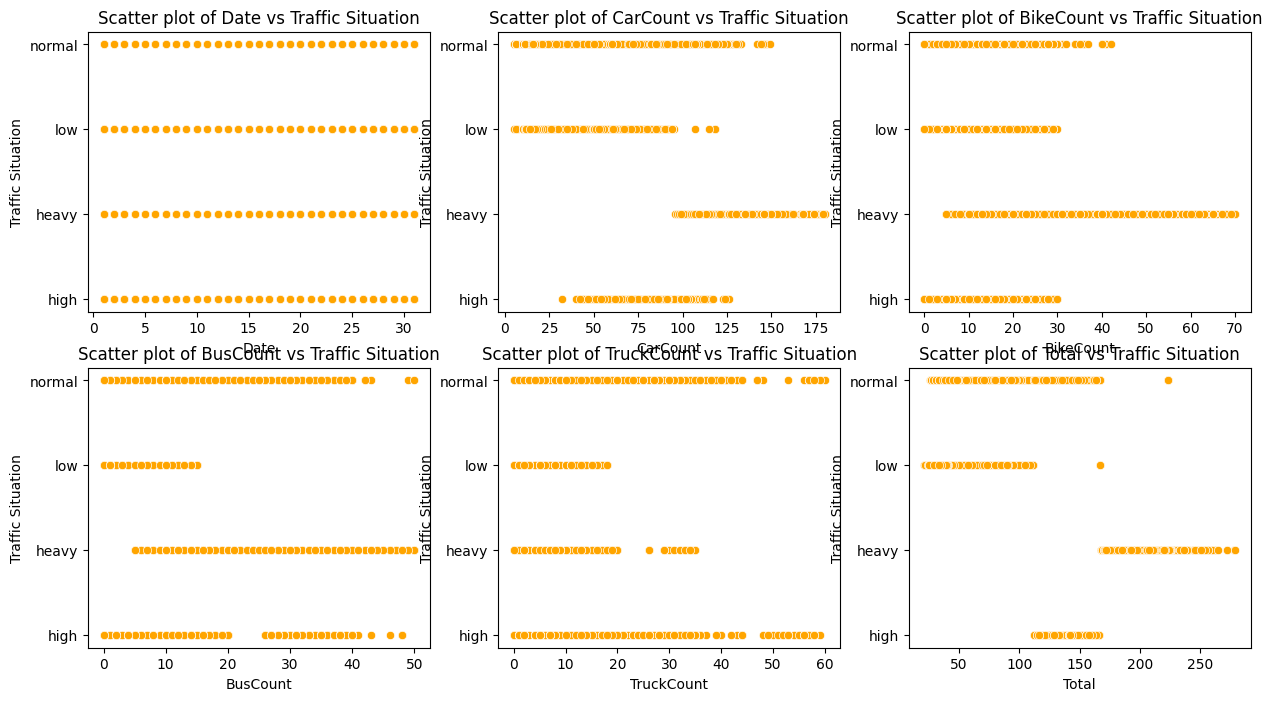

In [14]:
# Scatter plots for numerical columns
def scatterPlots(numerical_columns,data):
    plt.figure(figsize=(15, 8))
    for i, column in enumerate(numerical_columns, 1):
        plt.subplot(2, 3, i)
        sns.scatterplot(x=data[column], y=data['Traffic Situation'], color=['orange'])
        plt.title(f'Scatter plot of {column} vs Traffic Situation')
    plt.show()
scatterPlots(numerical_columns,data)

In [15]:
def removeOutliers(data,numerical_columns):
    Q1 = data[numerical_columns].quantile(0.25)
    Q3 = data[numerical_columns].quantile(0.75)
    IQR = Q3 - Q1
    filtered_entries_iqr = ~((data[numerical_columns] < (Q1 - 1.5 * IQR)) | (data[numerical_columns] > (Q3 + 1.5 * IQR))).any(axis=1)
    df = data[filtered_entries_iqr]
    return df
df = removeOutliers(data,numerical_columns)

In [16]:
df['Time'] = pd.to_datetime(df['Time'])

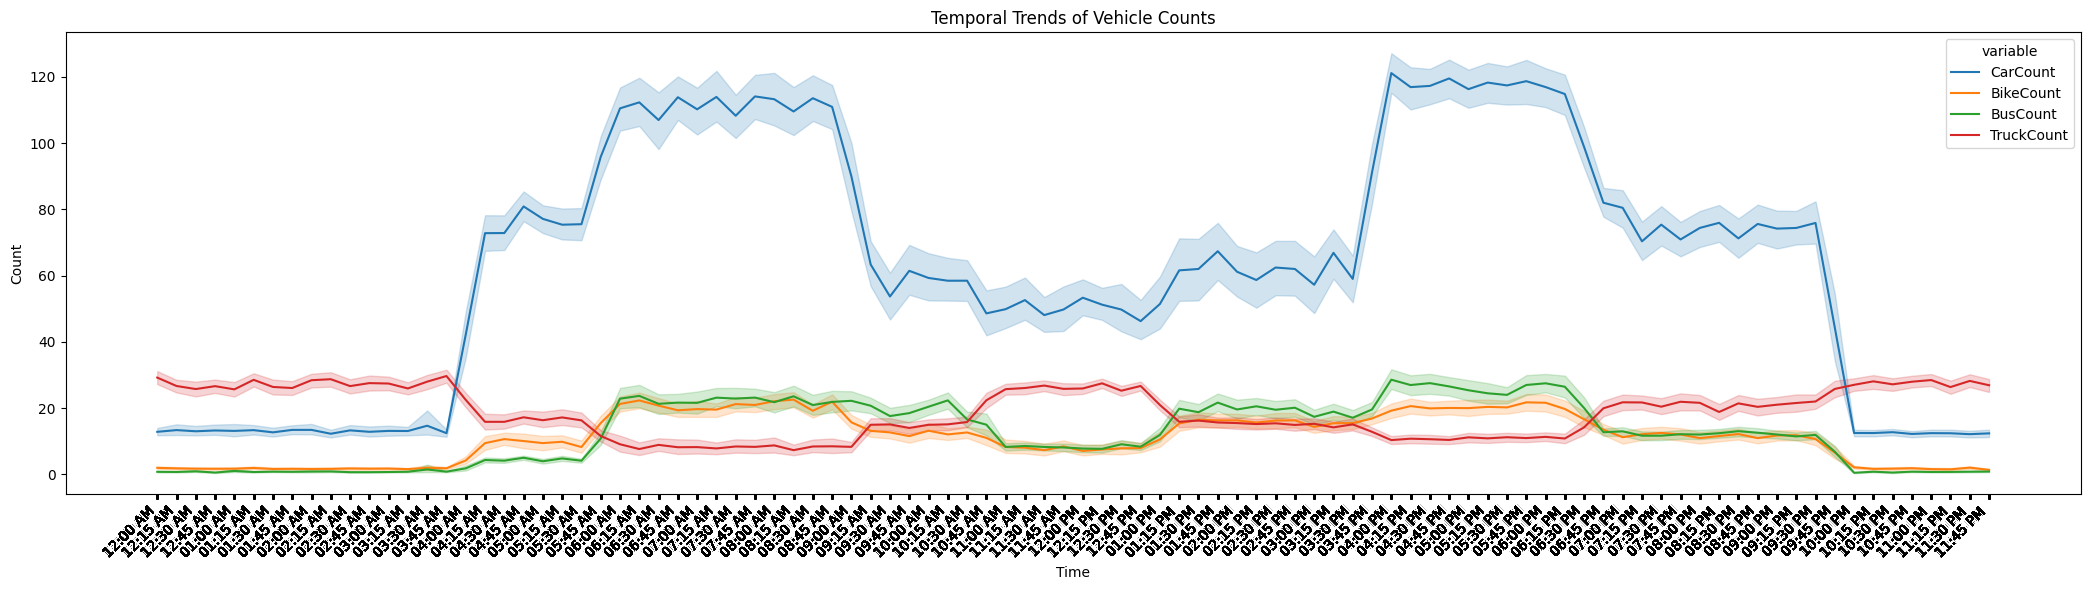

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Line plot for CarCount, BikeCount, BusCount, TruckCount
plt.figure(figsize=(26, 6))
sns.lineplot(x='Time', y='value', hue='variable', data=pd.melt(df[['Time', 'CarCount', 'BikeCount', 'BusCount', 'TruckCount']], ['Time']))

# Adjust X-axis ticks to display only the time part
plt.xticks(df['Time'], 
labels=df['Time'].dt.strftime('%I:%M %p'), rotation=45, ha='right')

plt.title('Temporal Trends of Vehicle Counts')
plt.xlabel('Time')
plt.ylabel('Count')
plt.show()


Class Distribution:
Traffic Situation
normal    3599
heavy      961
low        834
high       353
Name: count, dtype: int64


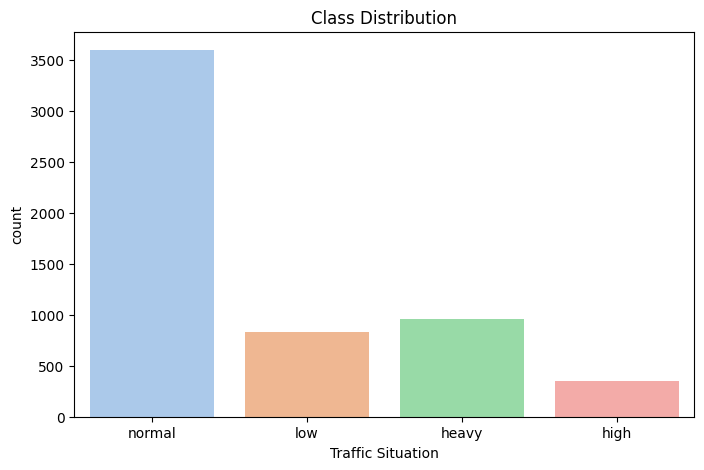

In [18]:
def classDistribution(df):
    class_counts = df['Traffic Situation'].value_counts()
    print("Class Distribution:")
    print(class_counts)
    plt.figure(figsize=(8, 5))
    sns.countplot(x='Traffic Situation', data=df, palette='pastel')
    plt.title('Class Distribution')
    plt.show()
classDistribution(df)

In [19]:
print(df.dtypes)
from sklearn.preprocessing import LabelEncoder

df['Traffic Situation'] = LabelEncoder().fit_transform(df['Traffic Situation'])
df['Day of the week'] = LabelEncoder().fit_transform(df['Day of the week'])

Time                 datetime64[ns]
Date                          int64
Day of the week              object
CarCount                      int64
BikeCount                     int64
BusCount                      int64
TruckCount                    int64
Total                         int64
Traffic Situation            object
dtype: object


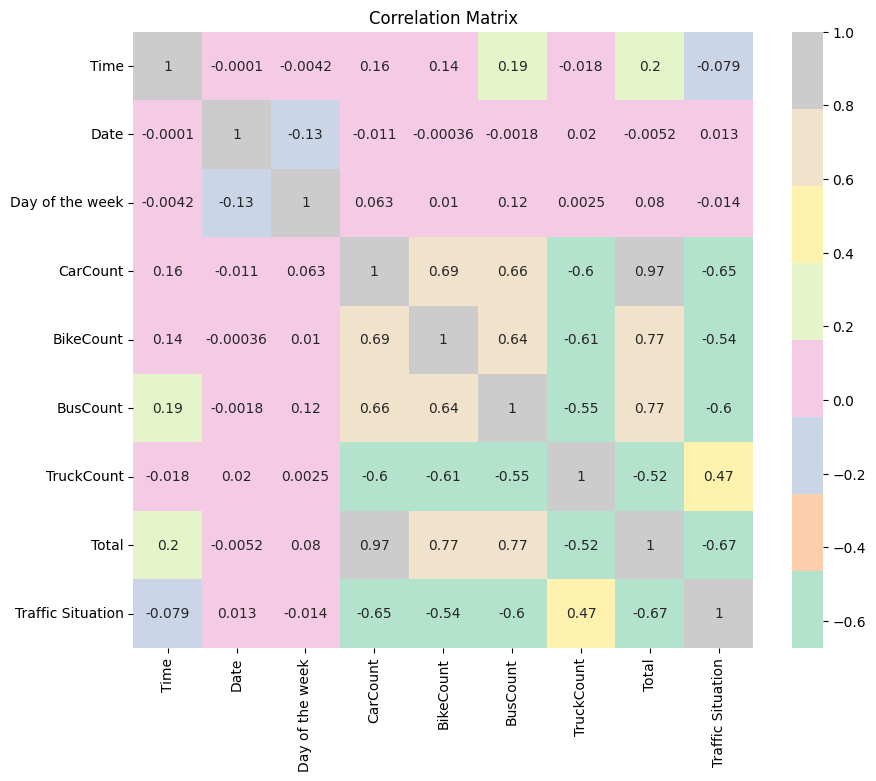

In [20]:
# Correlation heatmap for numerical columns
def correlationMatrix(df):
    correlation_matrix = df.corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='Pastel2')
    plt.title('Correlation Matrix')
    plt.show()
correlationMatrix(df)

## Feature Engineering

## Circular Encoding - Time Column

In [21]:
print(df.columns)


Index(['Time', 'Date', 'Day of the week', 'CarCount', 'BikeCount', 'BusCount',
       'TruckCount', 'Total', 'Traffic Situation'],
      dtype='object')


In [22]:
df['HourOfDay'] = df['Time'].dt.hour

# Apply circular encoding for the hour of the day
df['HourSin'] = np.sin(2 * np.pi * df['HourOfDay'] / 24)
df['HourCos'] = np.cos(2 * np.pi * df['HourOfDay'] / 24)

# Drop original 'Time' and 'HourOfDay' columns
df = df.drop(['Time', 'HourOfDay'], axis=1)

# Ensure 'Day of the week' is one-hot encoded
df = pd.get_dummies(df, columns=['Day of the week'])

# Ensure all columns are of numeric types for compatibility with SMOTE
df['Date'] = df['Date'].astype(float)  # Convert 'Date' to float if needed
float_columns = ['Day of the week_0', 'Day of the week_1', 'Day of the week_2',
                 'Day of the week_3', 'Day of the week_4', 'Day of the week_5','Day of the week_6']

# Convert selected columns to float
df[float_columns] = df[float_columns].astype(float)


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5747 entries, 0 to 5951
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               5747 non-null   float64
 1   CarCount           5747 non-null   int64  
 2   BikeCount          5747 non-null   int64  
 3   BusCount           5747 non-null   int64  
 4   TruckCount         5747 non-null   int64  
 5   Total              5747 non-null   int64  
 6   Traffic Situation  5747 non-null   int64  
 7   HourSin            5747 non-null   float64
 8   HourCos            5747 non-null   float64
 9   Day of the week_0  5747 non-null   float64
 10  Day of the week_1  5747 non-null   float64
 11  Day of the week_2  5747 non-null   float64
 12  Day of the week_3  5747 non-null   float64
 13  Day of the week_4  5747 non-null   float64
 14  Day of the week_5  5747 non-null   float64
 15  Day of the week_6  5747 non-null   float64
dtypes: float64(10), int64(6)
memo

In [24]:
df.columns

Index(['Date', 'CarCount', 'BikeCount', 'BusCount', 'TruckCount', 'Total',
       'Traffic Situation', 'HourSin', 'HourCos', 'Day of the week_0',
       'Day of the week_1', 'Day of the week_2', 'Day of the week_3',
       'Day of the week_4', 'Day of the week_5', 'Day of the week_6'],
      dtype='object')

## Seperating Features and Target Variable

In [25]:
X = df.drop('Traffic Situation', axis=1)
y = df['Traffic Situation']
le = LabelEncoder()
y = le.fit_transform(y)
# Assuming X is your feature matrix
imputer = SimpleImputer(strategy='mean')
X= imputer.fit_transform(X)

In [26]:
unique_labels = np.unique(y)
print(unique_labels)

[0 1 2 3]


## SMOTE

In [27]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)


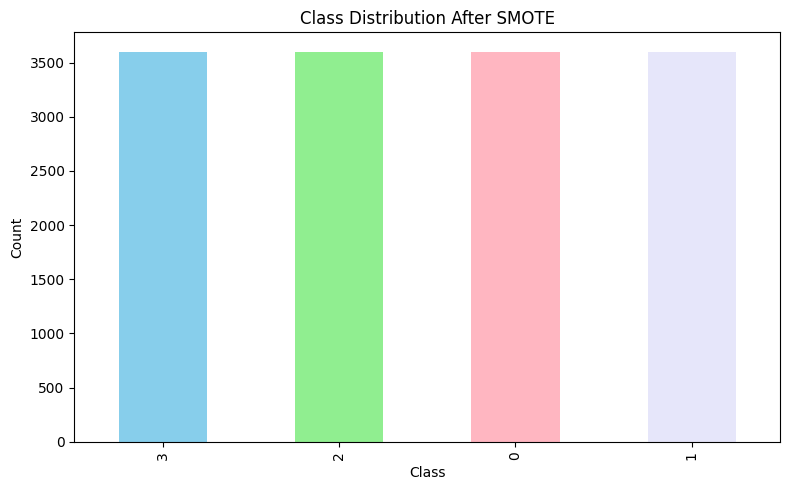

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))

y_resampled_series = pd.Series(y_resampled)
resampled_class_counts = y_resampled_series.value_counts()
resampled_class_counts.plot(kind='bar', ax=ax, color=['skyblue','lightgreen','lightpink','lavender'])
ax.set_title('Class Distribution After SMOTE')
ax.set_xlabel('Class')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

## Train - Test splitting

In [29]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

In [30]:
from sklearn.preprocessing import StandardScaler
# Initialize the StandardScaler
scaler = StandardScaler()
# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [31]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Classifiers

In [32]:

from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier
cl1 = LogisticRegression()
cl2 = RandomForestClassifier()
cl3 = SVC(probability=True)
cl4 = XGBClassifier()
cl5 = AdaBoostClassifier()

voting_cl = VotingClassifier(estimators = [('lr',cl1),('rf',cl2),('svc',cl3),
                                          ('xgb',cl4),('ada',cl5)], voting = 'hard')

voting_cl.fit(X_train_scaled, y_train)

VotingClassifier(estimators=[('lr', LogisticRegression()),
                             ('rf', RandomForestClassifier()),
                             ('svc', SVC(probability=True)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None...
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('ada', AdaBoostClassifier())])

In [33]:
voting_pred = voting_cl.predict(X_test_scaled)
accuracy = accuracy_score(y_test, voting_pred)
accuracy

0.9954861111111111

In [34]:
#Voting classfier using Cross_validation
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_val_score
for clf, label in zip([cl1,cl2,cl3,cl4,cl5],['lr','rf','svc','xgb','ada']):
    scores = cross_val_score(clf, X_train_scaled, y_train, scoring='accuracy', cv=5)
    print('Accuracy: ', (scores.mean(), label))

Accuracy:  (np.float64(0.9040462018140589), 'lr')
Accuracy:  (np.float64(0.9984368969218893), 'rf')
Accuracy:  (np.float64(0.9630946727095093), 'svc')
Accuracy:  (np.float64(0.9986105457253822), 'xgb')
Accuracy:  (np.float64(0.7864809864548656), 'ada')


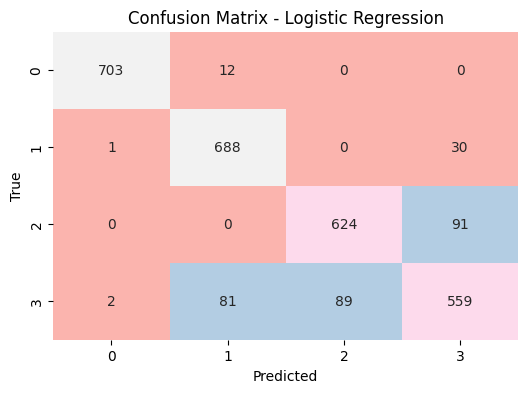

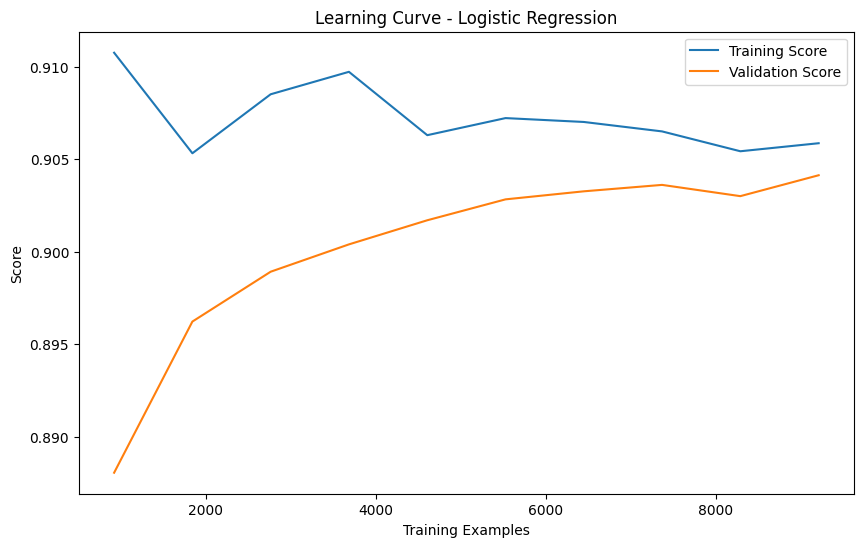

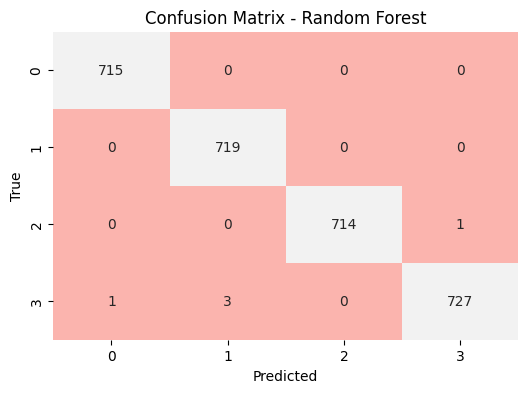

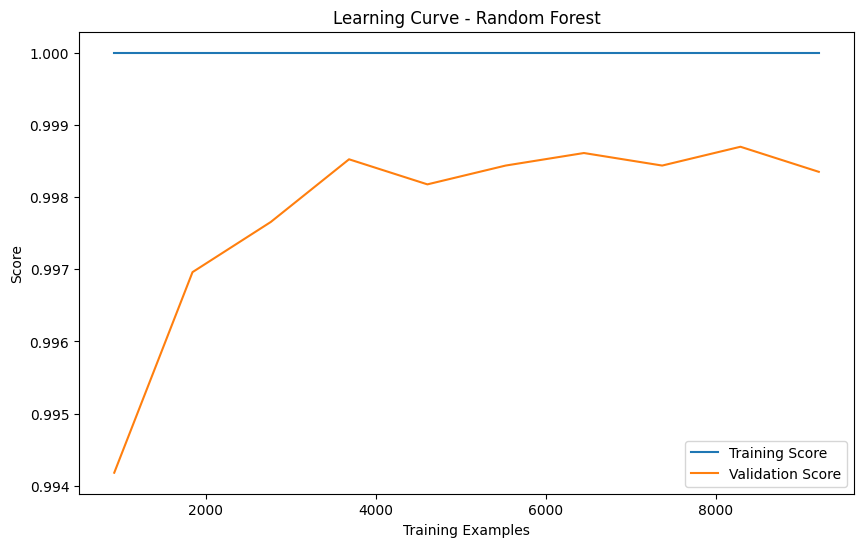

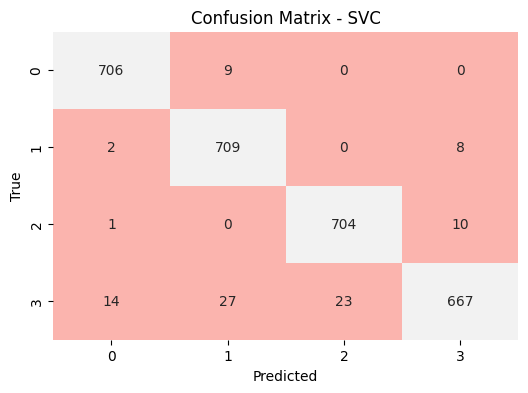

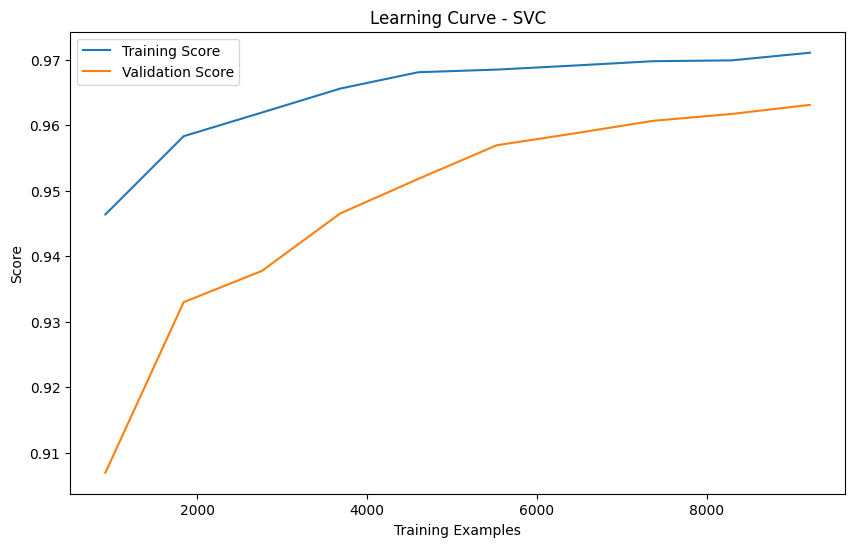

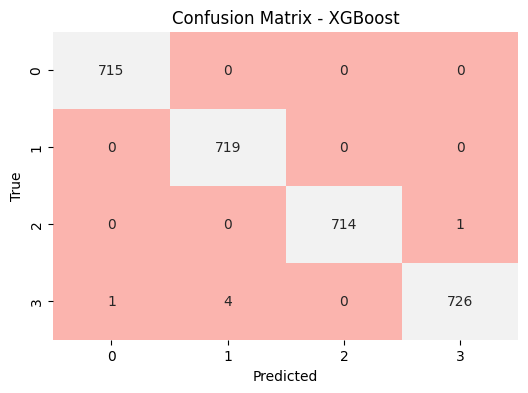

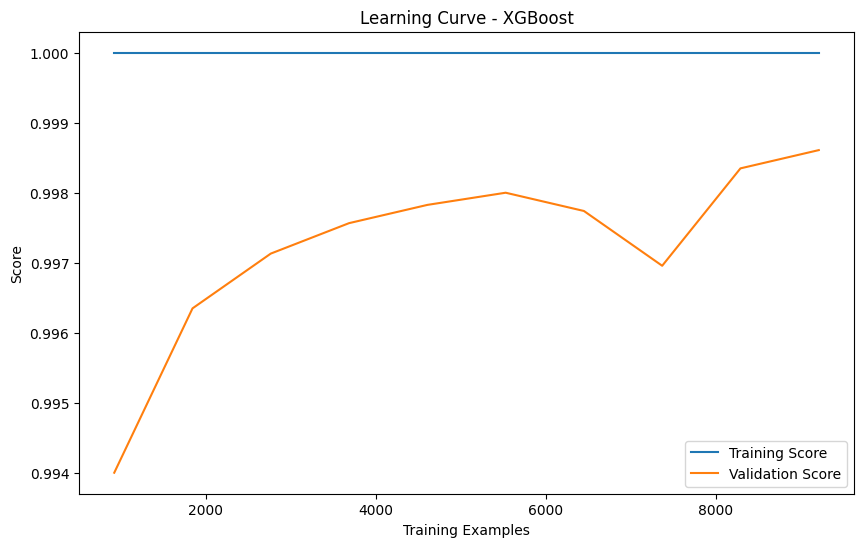

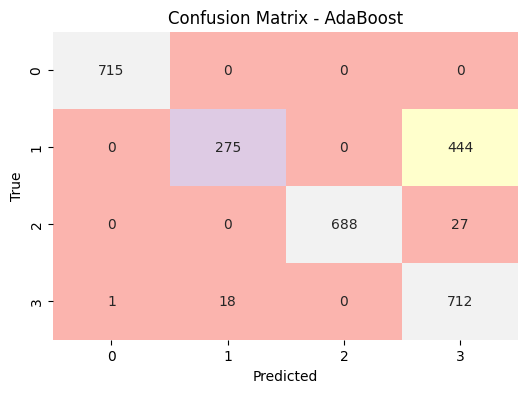

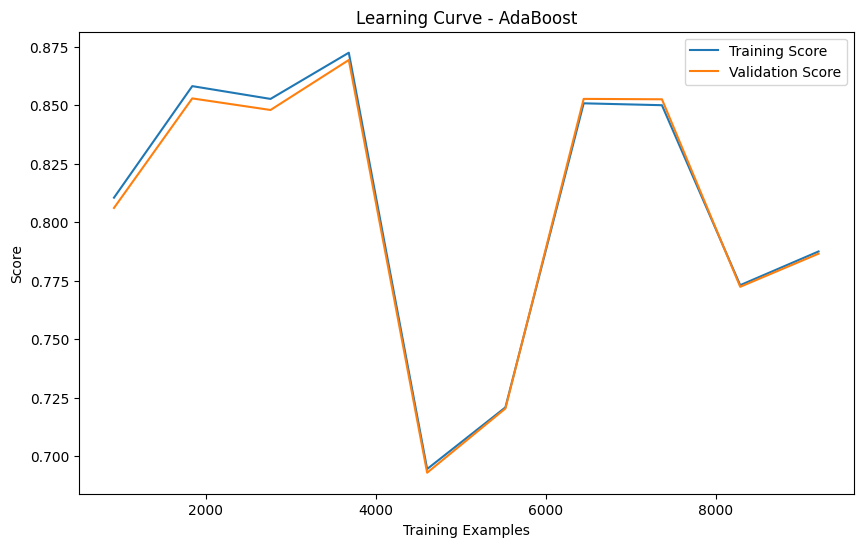

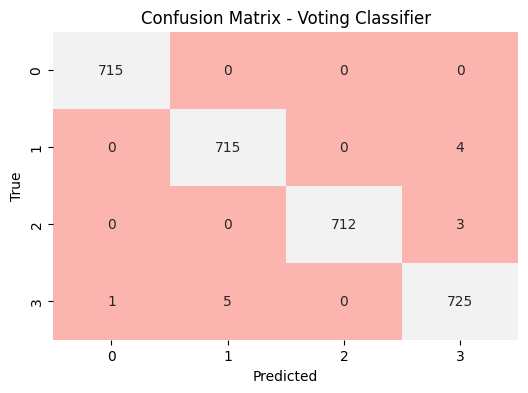

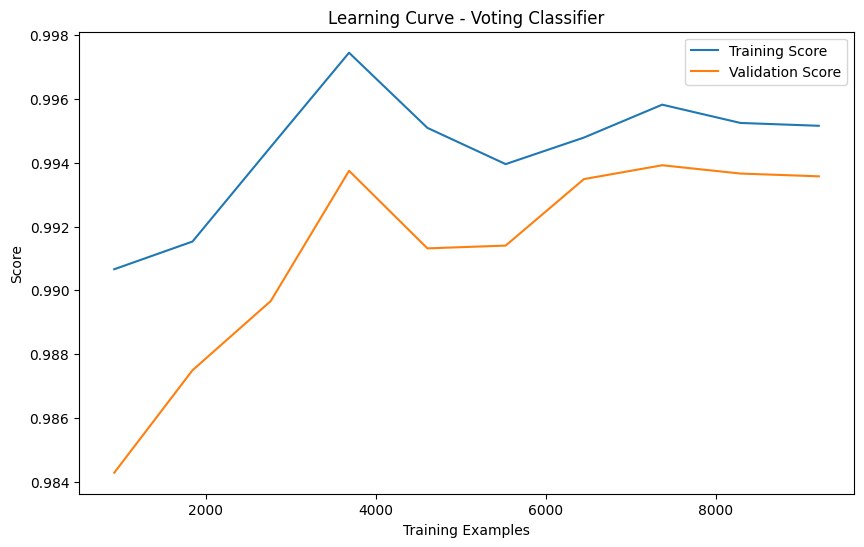

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.metrics import accuracy_score

# Confusion Matrix and Learning Curve for Each Classifier

classifiers = [cl1, cl2, cl3, cl4, cl5, voting_cl]
labels = ['Logistic Regression', 'Random Forest', 'SVC', 'XGBoost', 'AdaBoost', 'Voting Classifier']

# Fit each classifier before using it for prediction
for clf, label in zip(classifiers, labels):
    clf.fit(X_train_scaled, y_train)

# Confusion Matrix and Learning Curve for Each Classifier

for clf, label in zip(classifiers, labels):
    # Confusion Matrix
    y_pred = clf.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Pastel1', cbar=False)
    plt.title(f'Confusion Matrix - {label}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # Learning Curve
    train_sizes, train_scores, test_scores = learning_curve(
        clf, X_train_scaled, y_train, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10)
    )

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training Score')
    plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Validation Score')
    plt.title(f'Learning Curve - {label}')
    plt.xlabel('Training Examples')
    plt.ylabel('Score')
    plt.legend()
    plt.show()

In [37]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter Tuning for Each Classifier

# Logistic Regression
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}
grid_search_lr = GridSearchCV(cl1, param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_lr.fit(X_train_scaled, y_train)

best_lr_classifier = grid_search_lr.best_estimator_

# Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_rf = GridSearchCV(cl2, param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_rf.fit(X_train_scaled, y_train)

best_rf_classifier = grid_search_rf.best_estimator_

# SVC
param_grid_svc = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

grid_search_svc = GridSearchCV(cl3, param_grid_svc, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_svc.fit(X_train_scaled, y_train)

best_svc_classifier = grid_search_svc.best_estimator_

# XGBoost
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}

grid_search_xgb = GridSearchCV(cl4, param_grid_xgb, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_xgb.fit(X_train_scaled, y_train)

best_xgb_classifier = grid_search_xgb.best_estimator_

# AdaBoost
param_grid_ada = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid_search_ada = GridSearchCV(cl5, param_grid_ada, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_ada.fit(X_train_scaled, y_train)

best_ada_classifier = grid_search_ada.best_estimator_

# Voting Classifier (if desired)
voting_cl.set_params(estimators=[
    ('lr', best_lr_classifier),
    ('rf', best_rf_classifier),
    ('svc', best_svc_classifier),
    ('xgb', best_xgb_classifier),
    ('ada', best_ada_classifier)
])




VotingClassifier(estimators=[('lr', LogisticRegression(C=100)),
                             ('rf',
                              RandomForestClassifier(min_samples_split=10)),
                             ('svc',
                              SVC(C=100, gamma='auto', probability=True)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categoric...
                                            interaction_constraints=None,
                                            learning_rate=0.2, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=3,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=200, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('ada',
                              AdaBoostClassifier(learning_rate=0.2,
                                                 n_estimators=200))])

In [38]:
# Print Best Parameters for Each Classifier

print("Best Parameters for Logistic Regression:", grid_search_lr.best_params_)
print("Best Parameters for Random Forest:", grid_search_rf.best_params_)
print("Best Parameters for SVC:", grid_search_svc.best_params_)
print("Best Parameters for XGBoost:", grid_search_xgb.best_params_)
print("Best Parameters for AdaBoost:", grid_search_ada.best_params_)


Best Parameters for Logistic Regression: {'C': 100, 'penalty': 'l2'}
Best Parameters for Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best Parameters for SVC: {'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}
Best Parameters for XGBoost: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}
Best Parameters for AdaBoost: {'learning_rate': 0.2, 'n_estimators': 200}


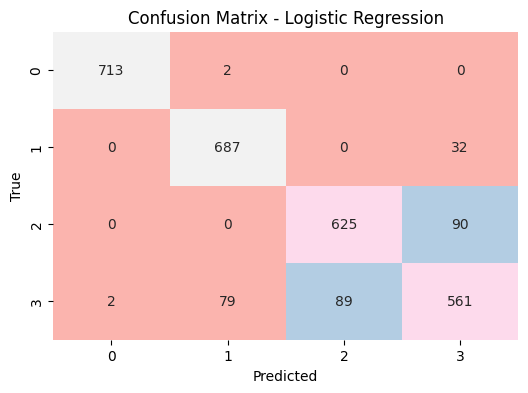

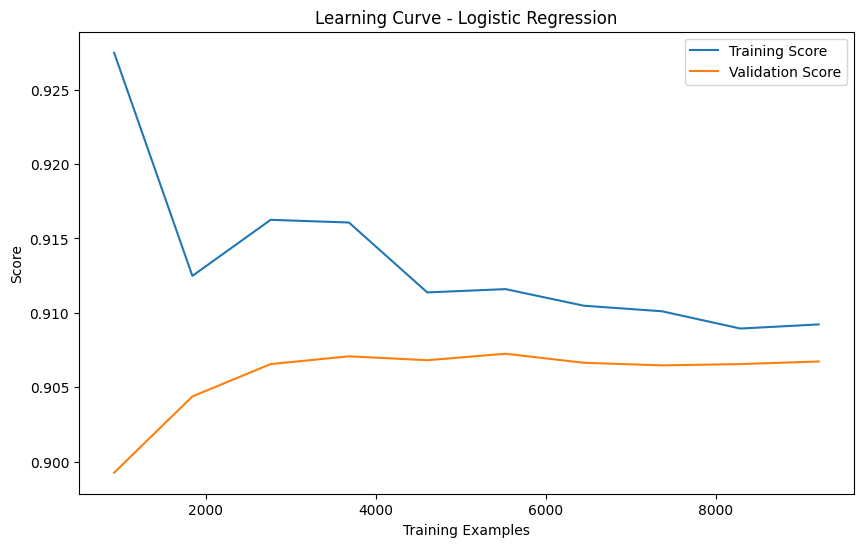

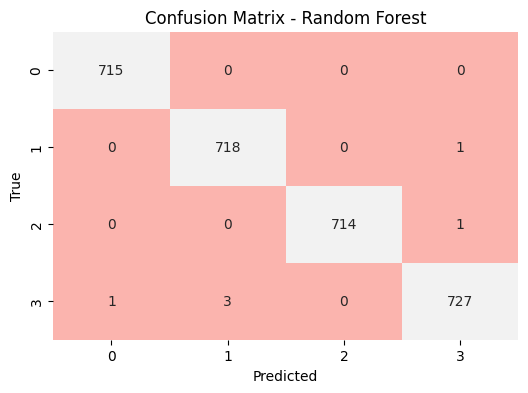

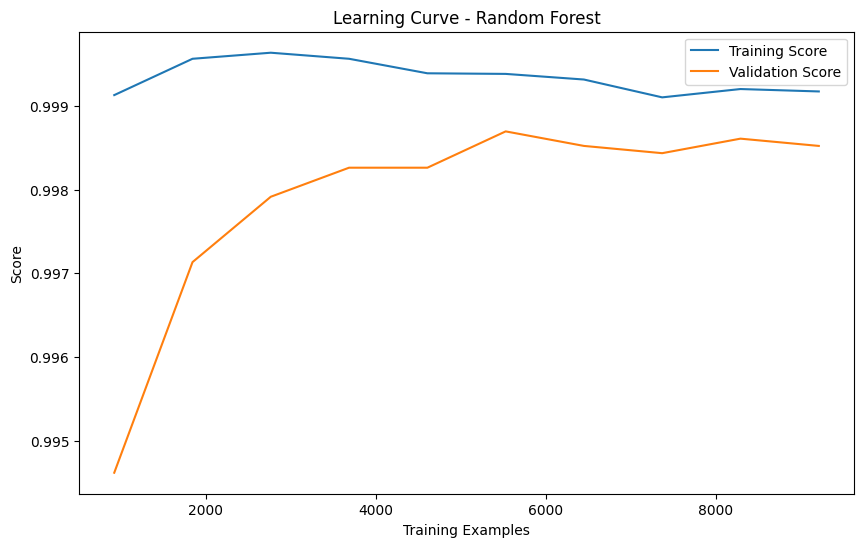

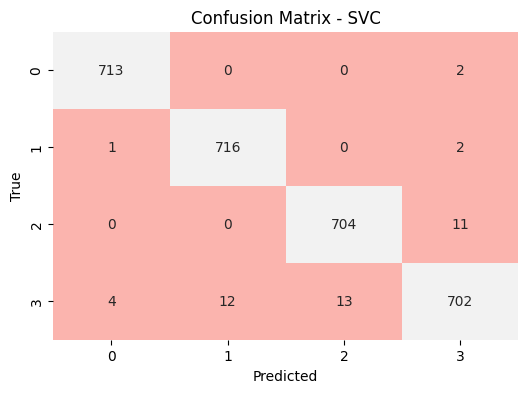

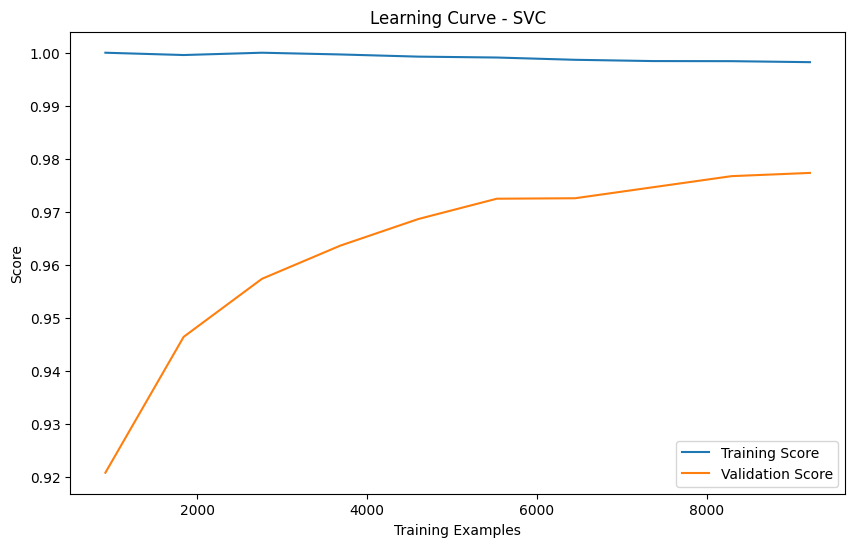

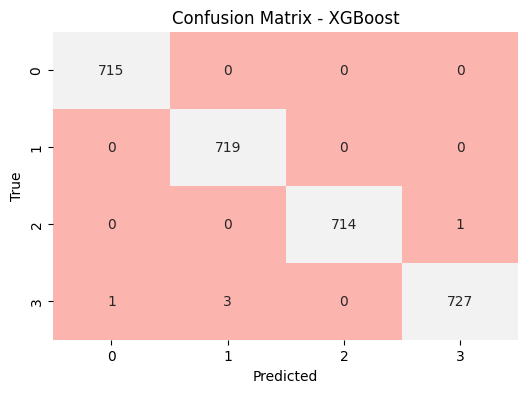

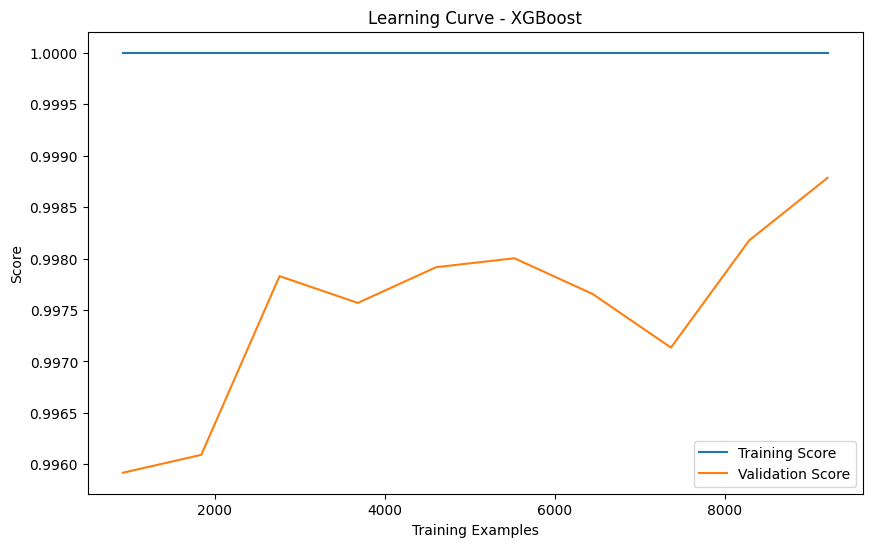

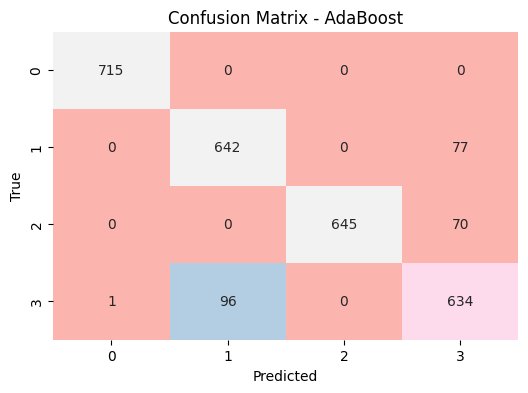

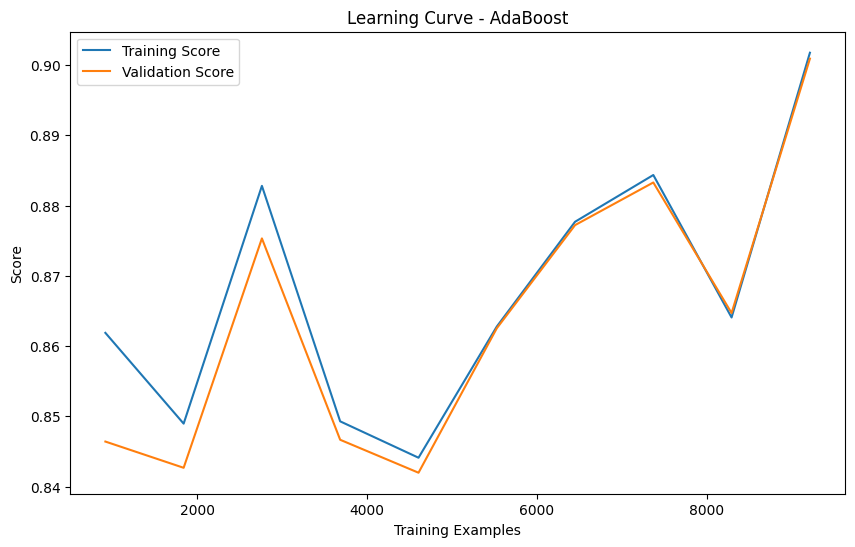

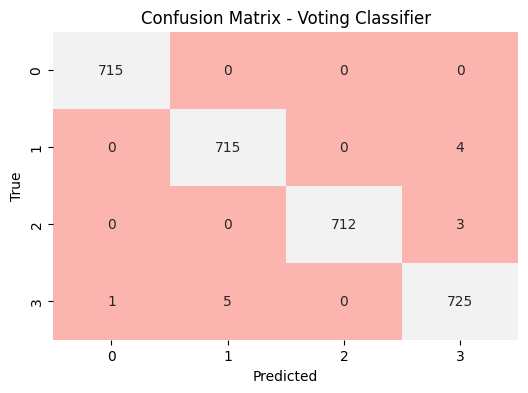

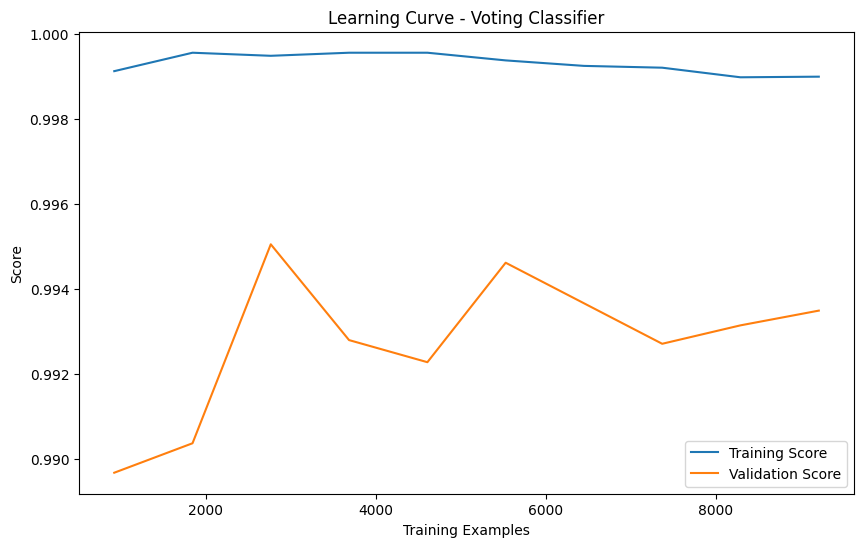

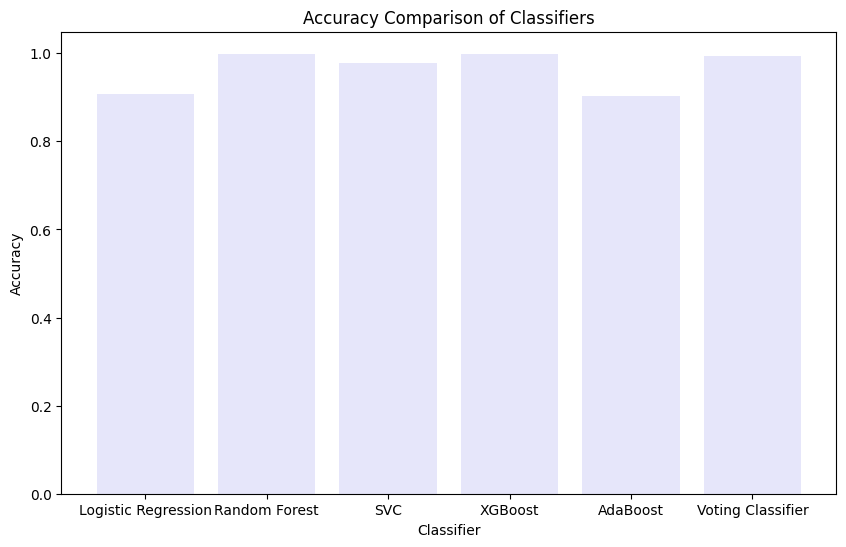

In [39]:
# Plotting Metrics for Classifiers with Best Parameters

classifiers = [
    grid_search_lr.best_estimator_,
    grid_search_rf.best_estimator_,
    grid_search_svc.best_estimator_,
    grid_search_xgb.best_estimator_,
    grid_search_ada.best_estimator_,
    voting_cl
]

labels = ['Logistic Regression', 'Random Forest', 'SVC', 'XGBoost', 'AdaBoost', 'Voting Classifier']

# Confusion Matrix and Learning Curve for Each Classifier

for clf, label in zip(classifiers, labels):
    # Confusion Matrix
    y_pred = clf.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Pastel1', cbar=False)
    plt.title(f'Confusion Matrix - {label}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # Learning Curve
    train_sizes, train_scores, test_scores = learning_curve(
        clf, X_train_scaled, y_train, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10)
    )

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training Score')
    plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Validation Score')
    plt.title(f'Learning Curve - {label}')
    plt.xlabel('Training Examples')
    plt.ylabel('Score')
    plt.legend()
    plt.show()

# Accuracy Comparison Plot

accuracy_scores = []

for clf, label in zip(classifiers, labels):
    scores = cross_val_score(clf, X_train_scaled, y_train, scoring='accuracy', cv=5)
    accuracy_scores.append(scores.mean())

plt.figure(figsize=(10, 6))
plt.bar(labels, accuracy_scores, color='lavender')
plt.title('Accuracy Comparison of Classifiers')
plt.xlabel('Classifier')
plt.ylabel('Accuracy')
plt.show()


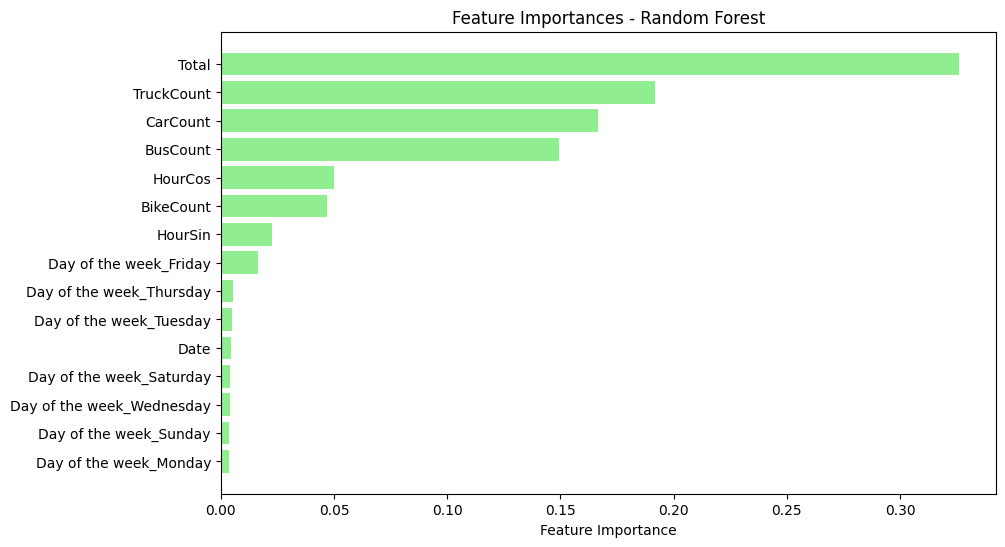

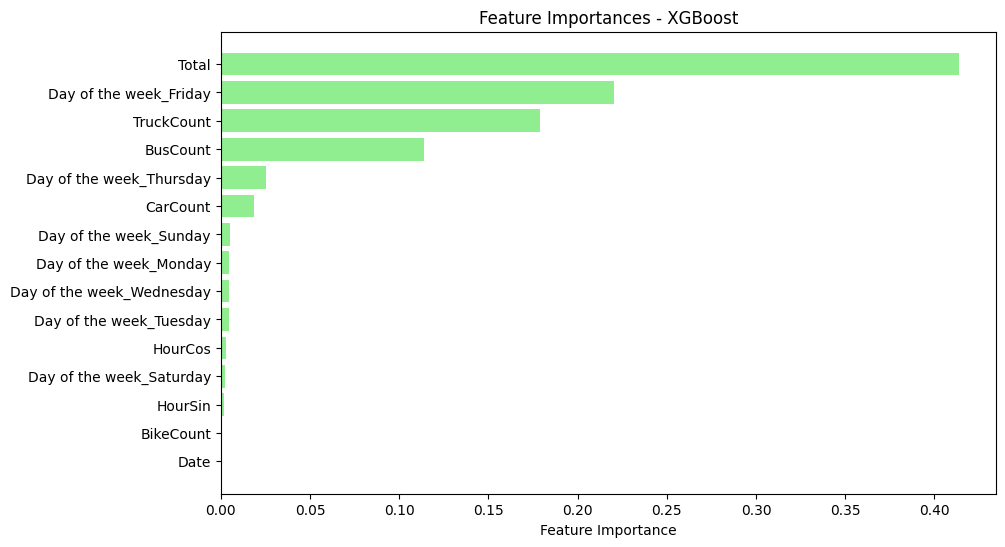

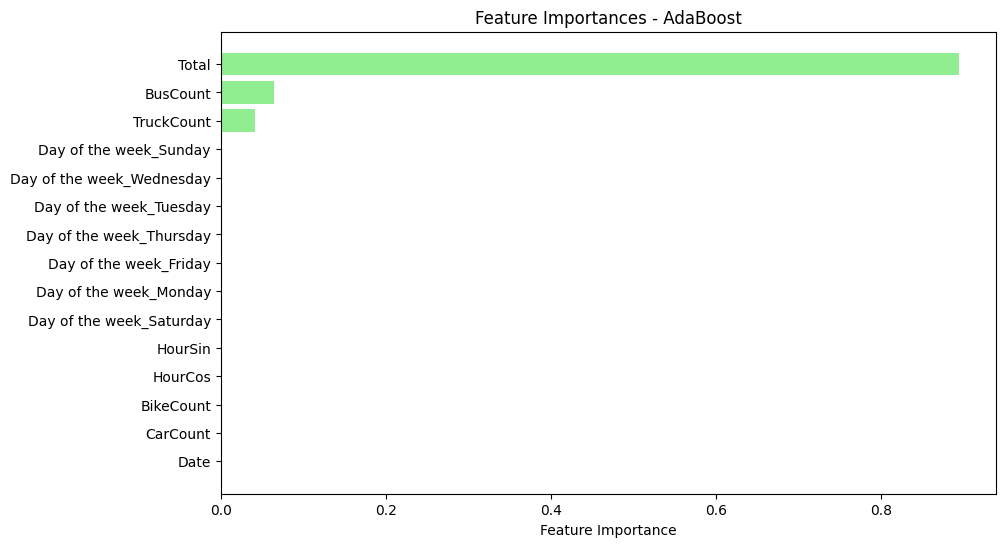

In [40]:
# Plot Feature Importances (if applicable)

for clf, label in zip(classifiers, labels):
    # Check if the classifier supports feature importances
    if hasattr(clf, 'feature_importances_'):
        feature_importances = clf.feature_importances_
        feature_names = ['Date', 'CarCount', 'BikeCount', 'BusCount', 'TruckCount', 'Total',
       'HourSin', 'HourCos', 'Day of the week_Friday',
       'Day of the week_Monday', 'Day of the week_Saturday',
       'Day of the week_Sunday', 'Day of the week_Thursday',
       'Day of the week_Tuesday', 'Day of the week_Wednesday']

        # Sort features by importance
        sorted_idx = np.argsort(feature_importances)

        # Plotting
        plt.figure(figsize=(10, 6))
        plt.barh(range(len(sorted_idx)), feature_importances[sorted_idx], align='center', color=['lightgreen'])
        plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
        plt.xlabel('Feature Importance')
        plt.title(f'Feature Importances - {label}')
        plt.show()


In [32]:
pip install --upgrade scikeras

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Creating and training neural network...
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2830 - loss: 1.4784
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4555 - loss: 1.2414
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5441 - loss: 1.0944
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7215 - loss: 0.8807
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7621 - loss: 0.7686
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7886 - loss: 0.6641
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7942 - loss: 0.6204
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8316 - loss: 0.5372
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8162 - loss: 0.5507
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8336 - loss: 0.5078
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

Neural Network Test Accuracy: 0.8200

Generating confusion matrix...
7/7 ━━━━━━━

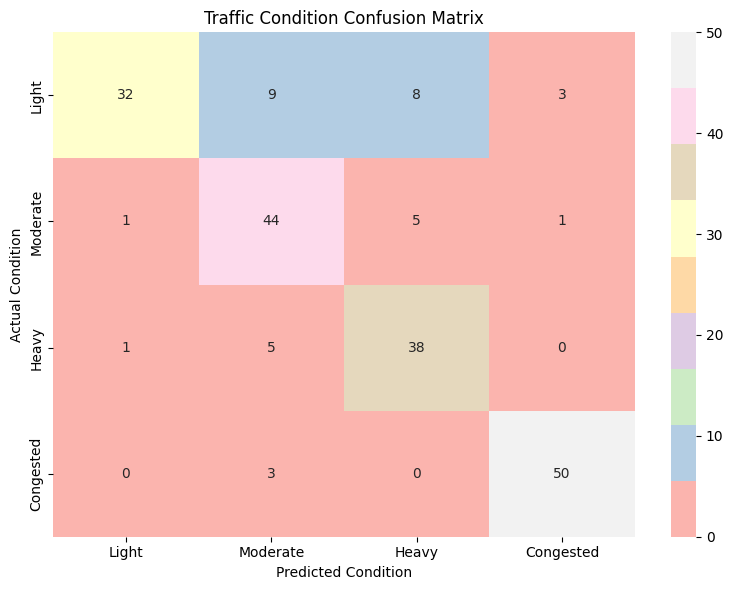


Generating learning curve (manual implementation)...


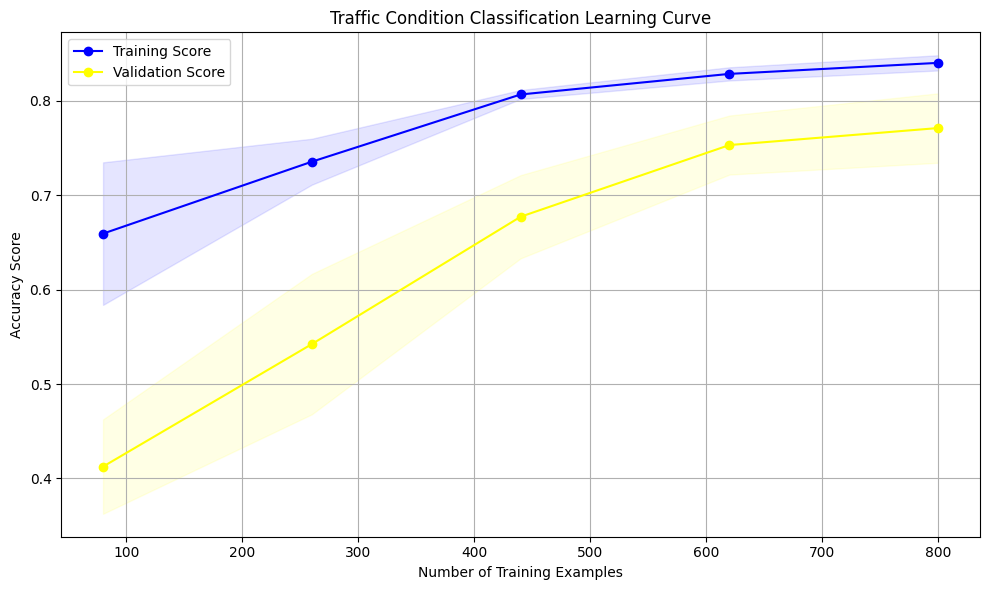

In [49]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from scikeras.wrappers import KerasClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import ShuffleSplit
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define the neural network model (modified to accept kwargs)
def create_nn_model(**kwargs):
    model = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(4, activation='softmax')
    ])
    model.compile(optimizer='adam', 
                loss='sparse_categorical_crossentropy', 
                metrics=['accuracy'])
    return model

# Create and train the model
print("Creating and training neural network...")
nn_cl = KerasClassifier(
    model=create_nn_model,  # Don't pass target_type here
    epochs=10,
    batch_size=32,
    verbose=1,
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Fit the model
nn_cl.fit(X_train_scaled, y_train)

# Evaluate performance
nn_accuracy = nn_cl.score(X_test_scaled, y_test)
print(f'\nNeural Network Test Accuracy: {nn_accuracy:.4f}')

# Confusion Matrix
print("\nGenerating confusion matrix...")
nn_y_pred = nn_cl.predict(X_test_scaled)
nn_cm = confusion_matrix(y_test, nn_y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(nn_cm, annot=True, fmt='d', cmap='Pastel1',
            xticklabels=['Light', 'Moderate', 'Heavy', 'Congested'],
            yticklabels=['Light', 'Moderate', 'Heavy', 'Congested'])
plt.title('Traffic Condition Confusion Matrix')
plt.xlabel('Predicted Condition')
plt.ylabel('Actual Condition')
plt.tight_layout()
plt.show()

# Manual Learning Curve Implementation
def manual_learning_curve(estimator, X, y, train_sizes, cv=5, random_state=42):
    train_scores = []
    val_scores = []
    
    cv_split = ShuffleSplit(n_splits=cv, test_size=0.2, random_state=random_state)
    
    for size in train_sizes:
        size_abs = int(size * len(X))
        fold_train_scores = []
        fold_val_scores = []
        
        for train_idx, val_idx in cv_split.split(X[:size_abs]):
            X_train_fold, X_val_fold = X[train_idx], X[val_idx]
            y_train_fold, y_val_fold = y[train_idx], y[val_idx]
            
            # Create fresh model each time
            model = KerasClassifier(
                model=create_nn_model,
                epochs=10,
                batch_size=32,
                verbose=0
            )
            model.fit(X_train_fold, y_train_fold)
            
            fold_train_scores.append(model.score(X_train_fold, y_train_fold))
            fold_val_scores.append(model.score(X_val_fold, y_val_fold))
        
        train_scores.append(fold_train_scores)
        val_scores.append(fold_val_scores)
    
    return (train_sizes * len(X), np.array(train_scores), np.array(val_scores))

print("\nGenerating learning curve (manual implementation)...")
train_sizes = np.linspace(0.1, 1.0, 5)
abs_sizes, train_scores, val_scores = manual_learning_curve(
    nn_cl, X_train_scaled, y_train, train_sizes
)

# Plotting the learning curve
plt.figure(figsize=(10, 6))
plt.plot(abs_sizes, np.mean(train_scores, axis=1), 'o-', color='blue', label='Training Score')
plt.plot(abs_sizes, np.mean(val_scores, axis=1), 'o-', color='yellow', label='Validation Score')
plt.fill_between(abs_sizes, 
                np.mean(train_scores, axis=1) - np.std(train_scores, axis=1),
                np.mean(train_scores, axis=1) + np.std(train_scores, axis=1),
                alpha=0.1, color='blue')
plt.fill_between(abs_sizes,
                np.mean(val_scores, axis=1) - np.std(val_scores, axis=1),
                np.mean(val_scores, axis=1) + np.std(val_scores, axis=1),
                alpha=0.1, color='yellow')
plt.title('Traffic Condition Classification Learning Curve')
plt.xlabel('Number of Training Examples')
plt.ylabel('Accuracy Score')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()